# Лабораторная работа №1: Базовая обработка изображений
**Темы:** Представление изображений, цветовые модели, точечные операции, гистограммы, контрастирование, бинаризация.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)

## 1. Загрузка и первичное исследование изображения
`cv2.imread` считывает изображение в формате **BGR**. Для корректного отображения в `matplotlib` необходимо перевести его в **RGB**.

In [2]:
image = cv2.imread('sar_2_color.jpg')

print(f"Форма массива (высота, ширина, каналы): {image.shape}")
print(f"Тип данных: {image.dtype}")
print(f"Значение пикселя (y=250, x=250) в формате BGR: {image[250, 250]}")

Форма массива (высота, ширина, каналы): (572, 974, 3)
Тип данных: uint8
Значение пикселя (y=250, x=250) в формате BGR: [12 12 12]


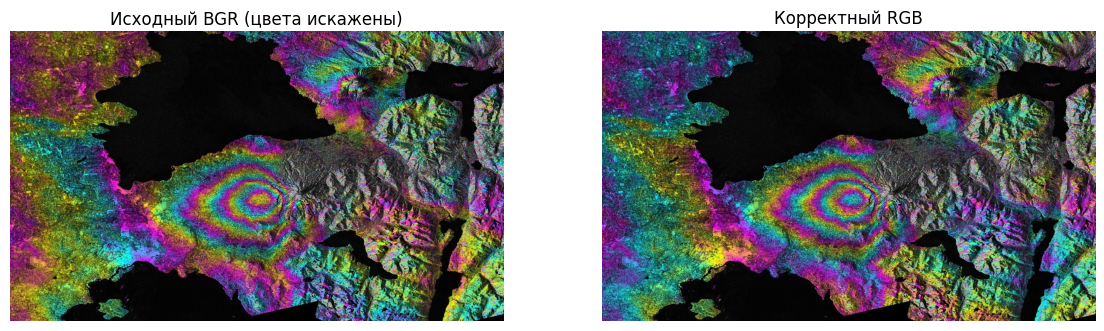

In [3]:
# Конвертация BGR в RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(image)
axes[0].set_title("Исходный BGR (цвета искажены)")
axes[0].axis('off')

axes[1].imshow(image_rgb)
axes[1].set_title("Корректный RGB")
axes[1].axis('off')
plt.show()

### Выделение области интереса (ROI — Region of Interest)

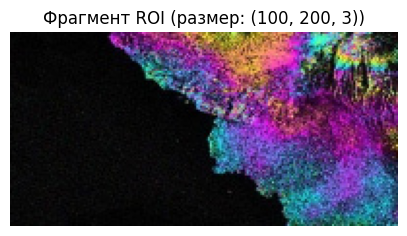

In [4]:
img_roi = image_rgb[100:200, 500:700]

plt.figure(figsize=(5, 5))
plt.imshow(img_roi)
plt.title(f"Фрагмент ROI (размер: {img_roi.shape})")
plt.axis('off')
plt.show()

## 2. Разделение каналов и цветовые пространства
Исследуем отдельные цветовые каналы R, G, B, а также перевод в градации серого, HSV и Lab.

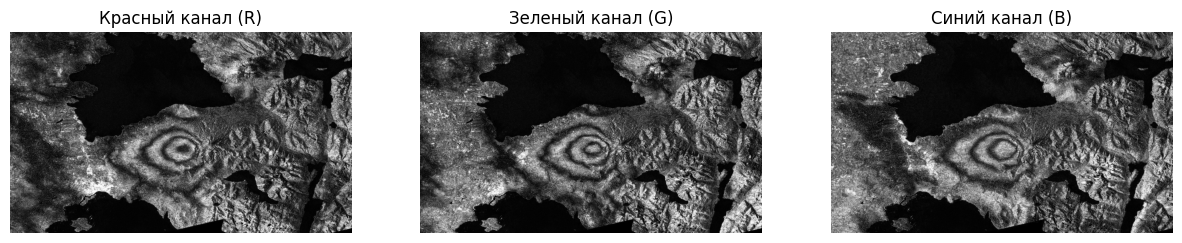

In [5]:
# Разделение каналов
r, g, b = cv2.split(image_rgb)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(r, cmap='gray')
axes[0].set_title("Красный канал (R)")
axes[0].axis('off')

axes[1].imshow(g, cmap='gray')
axes[1].set_title("Зеленый канал (G)")
axes[1].axis('off')

axes[2].imshow(b, cmap='gray')
axes[2].set_title("Синий канал (B)")
axes[2].axis('off')
plt.show()

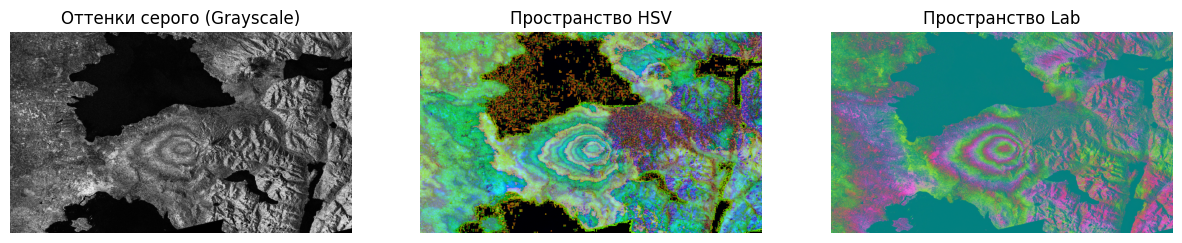

In [6]:
# Преобразование в оттенки серого
gray_cv = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

img_hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray_cv, cmap='gray')
axes[0].set_title("Оттенки серого (Grayscale)")
axes[0].axis('off')

axes[1].imshow(img_hsv)
axes[1].set_title("Пространство HSV")
axes[1].axis('off')

axes[2].imshow(img_lab)
axes[2].set_title("Пространство Lab")
axes[2].axis('off')
plt.show()

## 3. Точечные операции
Точечные операции зависят только от интенсивности текущего пикселя (гамма-коррекция, негатив).

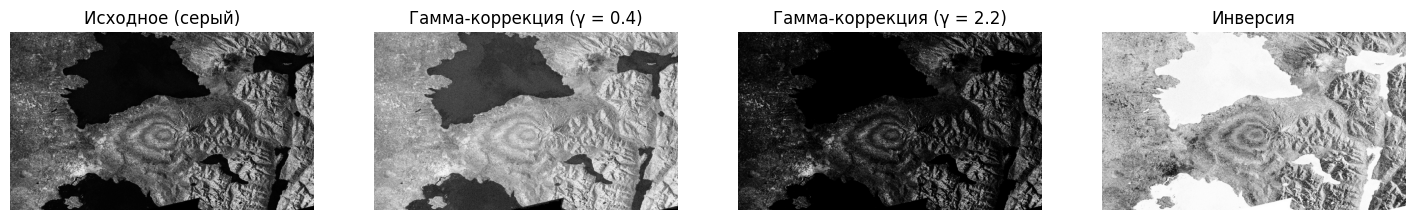

In [7]:
def gamma_correction(img, gamma=1.0):
    inv_gamma = gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(img, table)

gamma_light = gamma_correction(gray_cv, gamma=0.4)
gamma_dark = gamma_correction(gray_cv, gamma=2.2)
img_invert = 255 - gray_cv

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].imshow(gray_cv, cmap='gray')
axes[0].set_title("Исходное (серый)")
axes[0].axis('off')

axes[1].imshow(gamma_light, cmap='gray')
axes[1].set_title("Гамма-коррекция (γ = 0.4)")
axes[1].axis('off')

axes[2].imshow(gamma_dark, cmap='gray')
axes[2].set_title("Гамма-коррекция (γ = 2.2)")
axes[2].axis('off')

axes[3].imshow(img_invert, cmap='gray')
axes[3].set_title("Инверсия")
axes[3].axis('off')
plt.show()

## 4. Гистограмма и контрастирование
Построение распределения яркостей, линейное растяжение диапазона и эквализация гистограммы.

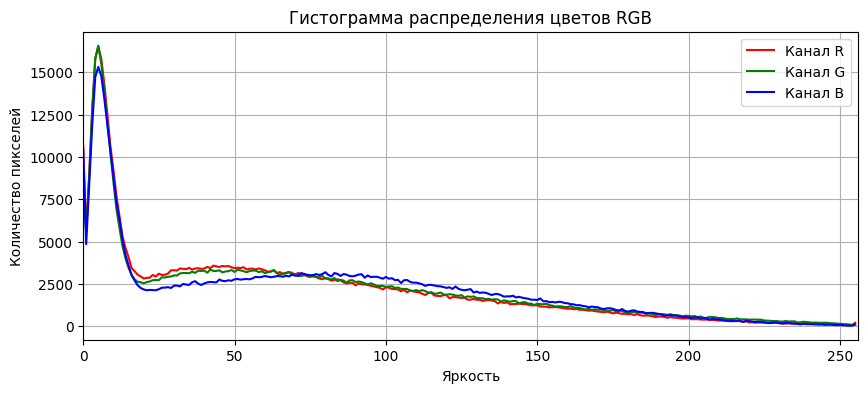

In [8]:
colors = ('r', 'g', 'b')
plt.figure(figsize=(10, 4))
for i, color in enumerate(colors):
    hist = cv2.calcHist([image_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f'Канал {color.upper()}')
plt.title("Гистограмма распределения цветов RGB")
plt.xlabel("Яркость")
plt.ylabel("Количество пикселей")
plt.xlim([0, 256])
plt.grid(True)
plt.legend()
plt.show()

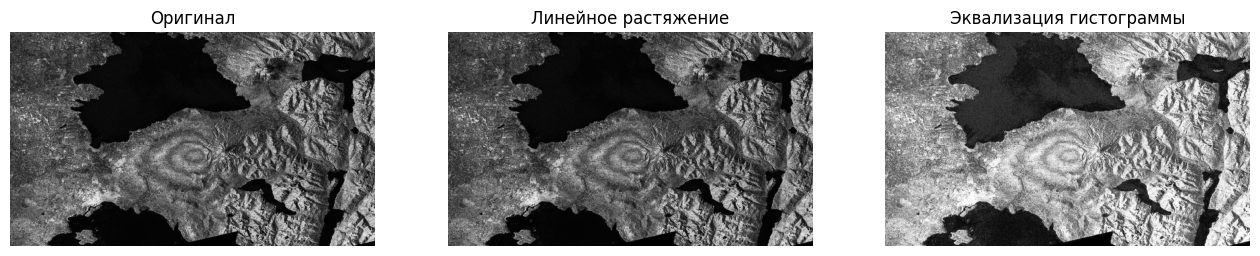

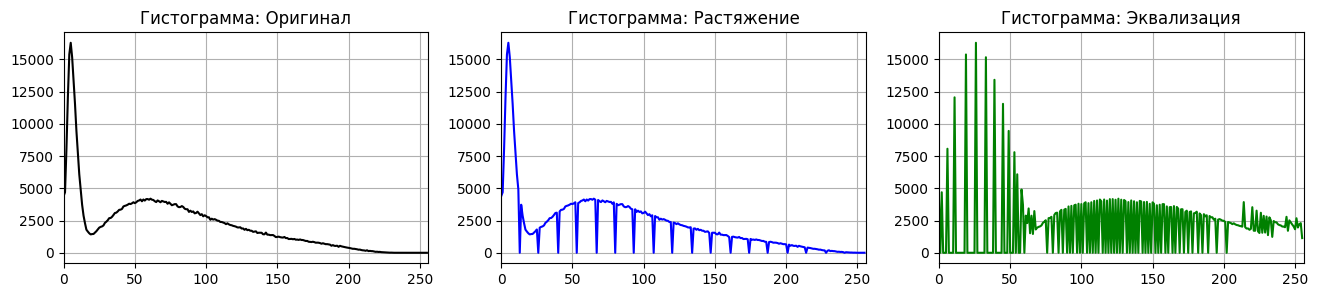

In [9]:
i_min, i_max = float(gray_cv.min()), float(gray_cv.max())
stretched = ((gray_cv - i_min) / (i_max - i_min) * 255.0).astype(np.uint8)

equalized = cv2.equalizeHist(gray_cv)

# Сравнение изображений
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(gray_cv, cmap='gray')
axes[0].set_title("Оригинал")
axes[0].axis('off')

axes[1].imshow(stretched, cmap='gray')
axes[1].set_title("Линейное растяжение")
axes[1].axis('off')

axes[2].imshow(equalized, cmap='gray')
axes[2].set_title("Эквализация гистограммы")
axes[2].axis('off')
plt.show()

# Сравнение их гистограмм
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
axes[0].plot(cv2.calcHist([gray_cv], [0], None, [256], [0, 256]), color='black')
axes[0].set_title("Гистограмма: Оригинал")
axes[1].plot(cv2.calcHist([stretched], [0], None, [256], [0, 256]), color='blue')
axes[1].set_title("Гистограмма: Растяжение")
axes[2].plot(cv2.calcHist([equalized], [0], None, [256], [0, 256]), color='green')
axes[2].set_title("Гистограмма: Эквализация")
for ax in axes:
    ax.grid(True)
    ax.set_xlim([0, 256])
plt.show()

## 5. Бинаризация изображения
Сравнение базовых пороговых методов фильтрации и адаптивного метода Оцу (Otsu).

Оптимальный порог методом оцу: 76.00


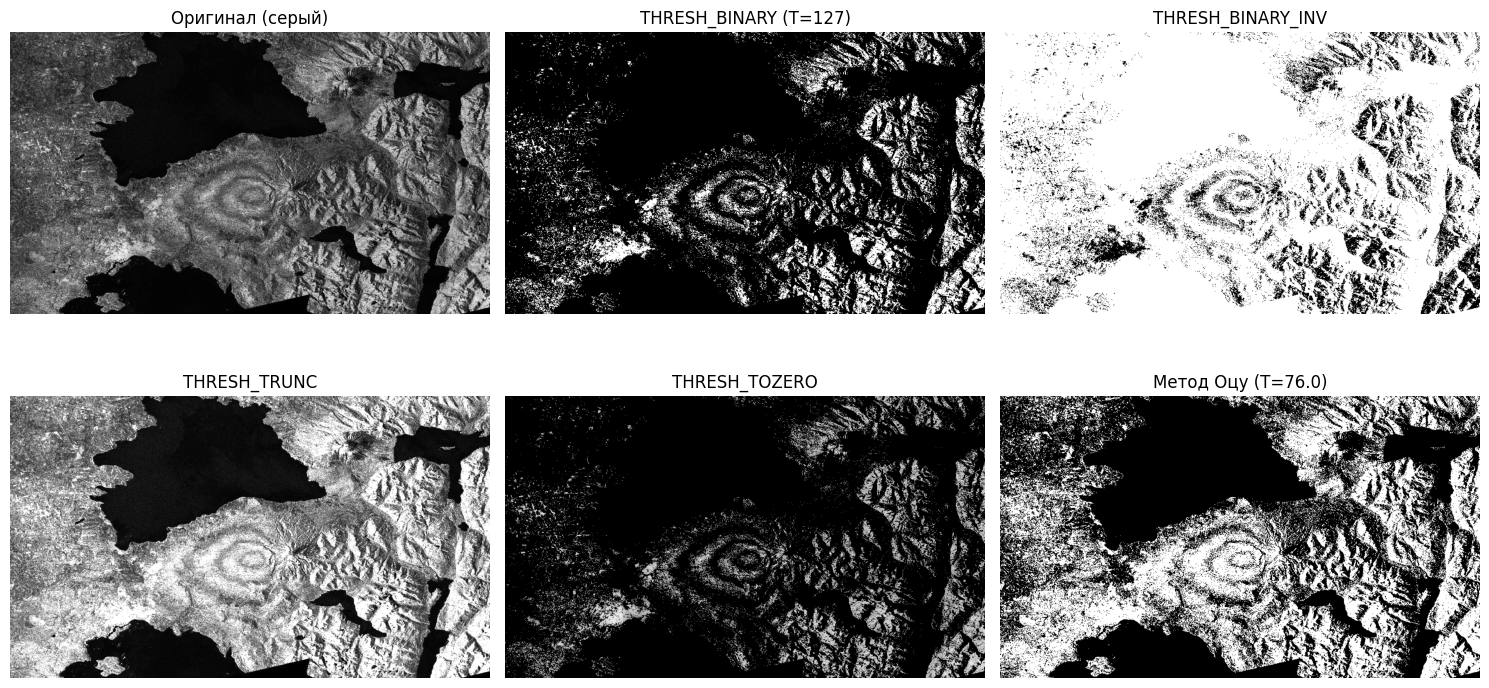

In [11]:
thresh = 127

_, bin_basic = cv2.threshold(gray_cv, thresh, 255, cv2.THRESH_BINARY)
_, bin_inv = cv2.threshold(gray_cv, thresh, 255, cv2.THRESH_BINARY_INV)
_, bin_trunc = cv2.threshold(gray_cv, thresh, 255, cv2.THRESH_TRUNC)
_, bin_tozero = cv2.threshold(gray_cv, thresh, 255, cv2.THRESH_TOZERO)

# Метод оцу
optimal_thresh, bin_otsu = cv2.threshold(gray_cv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Оптимальный порог методом оцу: {optimal_thresh:.2f}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes[0, 0].imshow(gray_cv, cmap='gray')
axes[0, 0].set_title("Оригинал (серый)")

axes[0, 1].imshow(bin_basic, cmap='gray')
axes[0, 1].set_title(f"THRESH_BINARY (T={thresh})")

axes[0, 2].imshow(bin_inv, cmap='gray')
axes[0, 2].set_title("THRESH_BINARY_INV")

axes[1, 0].imshow(bin_trunc, cmap='gray')
axes[1, 0].set_title("THRESH_TRUNC")

axes[1, 1].imshow(bin_tozero, cmap='gray')
axes[1, 1].set_title("THRESH_TOZERO")

axes[1, 2].imshow(bin_otsu, cmap='gray')
axes[1, 2].set_title(f"Метод оцу (T={optimal_thresh:.1f})")

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Метрика среднеквадратичной ошибки (MSE)
Оценка степени искажения изображения (например, исходного серого изображения и гамма-скорректированного).

In [13]:
def calculate_mse(image_a, image_b):
    return np.mean((image_a.astype("float") - image_b.astype("float")) ** 2)

mse_identical = calculate_mse(gray_cv, gray_cv)
mse_stretched = calculate_mse(gray_cv, stretched)
mse_gamma = calculate_mse(gray_cv, gamma_light)

print(f"MSE оригинала с самим собой: {mse_identical:.2f}")
print(f"MSE оригинала с растянутым: {mse_stretched:.2f}")
print(f"MSE оригинала с осветленным (гамма): {mse_gamma:.2f}")

MSE оригинала с самим собой: 0.00
MSE оригинала с растянутым: 41.87
MSE оригинала с осветленным (гамма): 4737.76
